# EDA: Beauty & Clothing Cross-Category Transfer Potential

**Goal**: Quantify how Clothing_Shoes_and_Jewelry data can improve cold-start recommendations for Beauty_and_Personal_Care.

Key questions:
1. How many users are active in both categories? (cross-category overlap)
2. Among cold-start Beauty users (< 5 reviews), how many are warm in Clothing (≥ 5 reviews)?
   → These users are directly addressable by cross-domain transfer learning.
3. Are rating behaviors and activity levels correlated across categories?
   → Positive correlation supports shared user representations.


In [1]:
import pandas as pd
import numpy as np
import json
import gzip
from typing import Any
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)

In [2]:
# --- Config ---
CATEGORIES: list[str] = ["Beauty_and_Personal_Care", "Clothing_Shoes_and_Jewelry"]
CAT_NAMES: dict[str, str] = {
    "Beauty_and_Personal_Care": "Beauty",
    "Clothing_Shoes_and_Jewelry": "Clothing",
}
SAMPLE_SIZE: int | None = None            # None = all rows
DATA_DIR: str = "../data"
RANDOM_SEED: int = 67

# Only include reviews that satisfy all of the following criteria
START_DATE: str | None = "2020-01-01"
END_DATE: str | None = "2022-12-31"
MIN_RATING: int | None = None

# Cold vs. warm users (matches pipeline config)
WARM_USER_MIN_REVIEWS: int = 5

COLORS: dict[str, str] = {
    "Beauty_and_Personal_Care": "#e91e8c",
    "Clothing_Shoes_and_Jewelry": "#3f51b5",
}

In [3]:
def stream_jsonl(path: str, fields: list[str] | None = None):
    with gzip.open(path, "rt", encoding="utf-8") as f:
        for _, line in enumerate(f):
            obj = json.loads(line)
            if fields is not None:
                obj = {k: obj.get(k) for k in fields}
            yield obj

def _date_to_ms(date_str: str | None) -> int | None:
    if date_str is None:
        return None
    return int(pd.Timestamp(date_str, tz="UTC").timestamp() * 1000)

def load_reviews(
    categories: list[str], sample_size: int | None = None,
    start_date: str | None = None, end_date: str | None = None,
    min_rating: int | None = None
) -> list[dict[str, Any]]:
    start_ts = _date_to_ms(start_date)
    end_ts = _date_to_ms(end_date)
    print(f"Filtering: start_date={start_date}, end_date={end_date}, min_rating={min_rating}")

    reviews: list[dict[str, Any]] = []
    for cat in categories:
        path = f"{DATA_DIR}/{cat}.jsonl.gz"
        print(f"Loading: {path}")
        for obj in stream_jsonl(path, fields=[
            'user_id', 'parent_asin', 'rating', 'timestamp'
        ]):
            ts: Any = obj.get("timestamp")
            rating: Any = obj.get("rating")
            if start_ts is not None and (ts is not None and ts < start_ts):
                continue
            if end_ts is not None and (ts is not None and ts > end_ts):
                continue
            if min_rating is not None and (rating is not None and rating < min_rating):
                continue
            obj["category"] = cat
            reviews.append(obj)

            if sample_size is not None and len(reviews) >= sample_size:
                print(f"Reached sample size limit ({sample_size}). Stopping.")
                break
    return reviews

## Load full datasets

**Memory note**: Beauty ~11M reviews, Clothing ~29M reviews. Combined DataFrame ~1.5 GB.

In [4]:
reviews = load_reviews(
    CATEGORIES, sample_size=SAMPLE_SIZE, start_date=START_DATE, end_date=END_DATE,
    min_rating=MIN_RATING
)
print(f"Loaded {len(reviews):,} reviews total")

df_reviews = pd.DataFrame(reviews)
display(df_reviews.head())
df_reviews.info()

del reviews  # free memory after creating DataFrame

Filtering: start_date=2020-01-01, end_date=2022-12-31, min_rating=None
Loading: ../data/Beauty_and_Personal_Care.jsonl.gz
Loading: ../data/Clothing_Shoes_and_Jewelry.jsonl.gz
Loaded 39,991,553 reviews total


,user_id,parent_asin,rating,timestamp,category
0,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B00Z03RC80,1.0,1616743454733,Beauty_and_Personal_Care
1,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B085PRT2MP,1.0,1614915977684,Beauty_and_Personal_Care
2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B08G81QQ9L,5.0,1612052493701,Beauty_and_Personal_Care
3,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B07YYG76X1,1.0,1609700981786,Beauty_and_Personal_Care
4,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B07X4FKLNK,3.0,1581313195358,Beauty_and_Personal_Care


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39991553 entries, 0 to 39991552
Data columns (total 5 columns):
 #   Column       Dtype  
---  ------       -----  
 0   user_id      object 
 1   parent_asin  object 
 2   rating       float64
 3   timestamp    int64  
 4   category     object 
dtypes: float64(1), int64(1), object(3)
memory usage: 1.5+ GB


## 1. Cross-Category User Overlap

How many users appear in both categories?

In [5]:
user_sets = {
    cat: set(df_reviews[df_reviews["category"] == cat]["user_id"].unique())
    for cat in CATEGORIES
}

beauty_users = user_sets[CATEGORIES[0]]
clothing_users = user_sets[CATEGORIES[1]]
overlap = beauty_users & clothing_users

print(f"Beauty-only users:        {len(beauty_users - clothing_users):>10,}")
print(f"Clothing-only users:       {len(clothing_users - beauty_users):>10,}")
print(f"Users in both categories:  {len(overlap):>10,}")
print(f"Total unique users:        {len(beauty_users | clothing_users):>10,}")
print()
print(f"% of Beauty users also in Clothing: {100 * len(overlap) / max(len(beauty_users), 1):.2f}%")
print(f"% of Clothing users also in Beauty: {100 * len(overlap) / max(len(clothing_users), 1):.2f}%")

Beauty-only users:         2,841,968
Clothing-only users:        9,502,057
Users in both categories:   3,308,207
Total unique users:        15,652,232

% of Beauty users also in Clothing: 53.79%
% of Clothing users also in Beauty: 25.82%


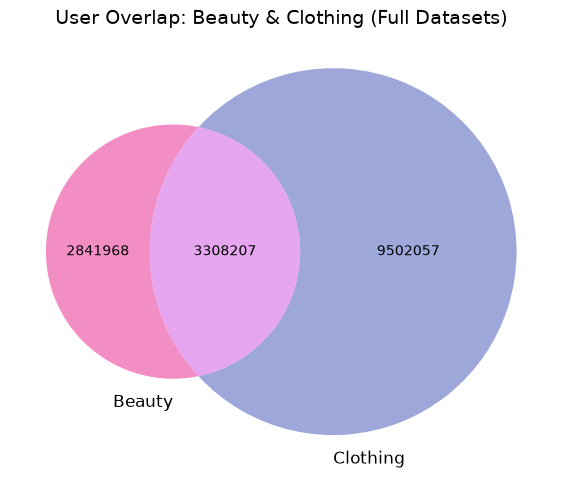

In [6]:
plt.figure(figsize=(7, 7))
venn2(
    [beauty_users, clothing_users],
    set_labels=("Beauty", "Clothing"),
    set_colors=[COLORS[cat] for cat in CATEGORIES],
    alpha=0.5
)
plt.title("User Overlap: Beauty & Clothing (Full Datasets)", fontsize=14)
plt.show()

## 2. Rating & Activity Correlation

Do users behave consistently across categories? Modest positive correlations hint at shared rating patterns across domains.

In [15]:
avg_ratings = {}
for cat in CATEGORIES:
    name = CAT_NAMES[cat]
    avg_ratings[name] = (
        df_reviews[df_reviews["category"] == cat]
        .groupby("user_id")["rating"]
        .mean()
        .rename(f"avg_{name}")
    )

rating_profile = pd.concat(avg_ratings.values(), axis=1).dropna()
rating_r = rating_profile.iloc[:, 0].corr(rating_profile.iloc[:, 1])
print(f"Users with ratings in both categories: {len(rating_profile):,}")
print(f"Rating correlation (Beauty vs Clothing): r = {rating_r:.4f}")
print("→ Modest positive correlation — users who rate highly in one tend to rate slightly higher in the other (r\u00b2 \u2248 0.07, ~7% shared variance).")

Users with ratings in both categories: 3,308,207
Rating correlation (Beauty vs Clothing): r = 0.2658
→ Modest positive correlation — users who rate highly in one tend to rate slightly higher in the other (r² ≈ 0.07, ~7% shared variance).


In [16]:
overlap_profile = user_profile[
    (user_profile["beauty_count"] > 0) & (user_profile["clothing_count"] > 0)
].copy()

act_r_raw = overlap_profile["beauty_count"].corr(overlap_profile["clothing_count"])
act_r_log = np.log10(overlap_profile["beauty_count"] + 1).corr(
    np.log10(overlap_profile["clothing_count"] + 1)
)
print(f"Users active in both categories: {len(overlap_profile):,}")
print(f"Activity correlation (raw):       r = {act_r_raw:.4f}")
print(f"Activity correlation (log):       r = {act_r_log:.4f}")
print("→ Activity levels correlate, so 'warmth' transfers across domains.")

Users active in both categories: 3,308,207
Activity correlation (raw):       r = 0.3969
Activity correlation (log):       r = 0.3961
→ Activity levels correlate, so 'warmth' transfers across domains.


## 3. Cold-Start Analysis

**Definition**: Users with < 5 reviews in Beauty are "cold" in Beauty.

**Key metric**: Among cold Beauty users, how many are "warm" in Clothing (≥ 5 reviews)?
These are users whose Clothing history can bootstrap Beauty recommendations via cross-domain transfer.

In [17]:
beauty_activity = df_reviews[df_reviews["category"] == CATEGORIES[0]].groupby("user_id").size().rename("beauty_count")
clothing_activity = df_reviews[df_reviews["category"] == CATEGORIES[1]].groupby("user_id").size().rename("clothing_count")

user_profile = (
    beauty_activity.to_frame()
    .join(clothing_activity, how="outer")
    .fillna(0)
    .astype(int)
)

In [18]:
in_beauty = user_profile["beauty_count"] > 0
cold_in_beauty = user_profile[in_beauty & (user_profile["beauty_count"] < WARM_USER_MIN_REVIEWS)]
warm_in_beauty = user_profile[in_beauty & (user_profile["beauty_count"] >= WARM_USER_MIN_REVIEWS)]

has_clothing_warm = (cold_in_beauty["clothing_count"] >= WARM_USER_MIN_REVIEWS).sum()
has_clothing_any = (cold_in_beauty["clothing_count"] > 0).sum()

total_beauty = in_beauty.sum()
cold_count = len(cold_in_beauty)

print(f"Total Beauty users:                        {total_beauty:>8,}")
print(f"  Cold in Beauty (< {WARM_USER_MIN_REVIEWS} reviews):    {cold_count:>8,}  ({100*cold_count/total_beauty:.1f}%)")
print(f"  Warm in Beauty (≥ {WARM_USER_MIN_REVIEWS}):         {len(warm_in_beauty):>8,}  ({100*len(warm_in_beauty)/total_beauty:.1f}%)\n")

print(f"Of {cold_count:,} cold Beauty users:")
print(f"  Warm in Clothing (≥{WARM_USER_MIN_REVIEWS}): {has_clothing_warm:>8,}  ({100*has_clothing_warm/cold_count:.1f}%)")
print(f"  Any Clothing activity:  {has_clothing_any:>8,}  ({100*has_clothing_any/cold_count:.1f}%)\n")
print("→ The 'warm in Clothing' group can benefit from cross-domain transfer.")

Total Beauty users:                        6,150,175
  Cold in Beauty (< 5 reviews):    5,851,883  (95.1%)
  Warm in Beauty (≥ 5):          298,292  (4.9%)

Of 5,851,883 cold Beauty users:
  Warm in Clothing (≥5):  591,576  (10.1%)
  Any Clothing activity:  3,049,815  (52.1%)

→ The 'warm in Clothing' group can benefit from cross-domain transfer.


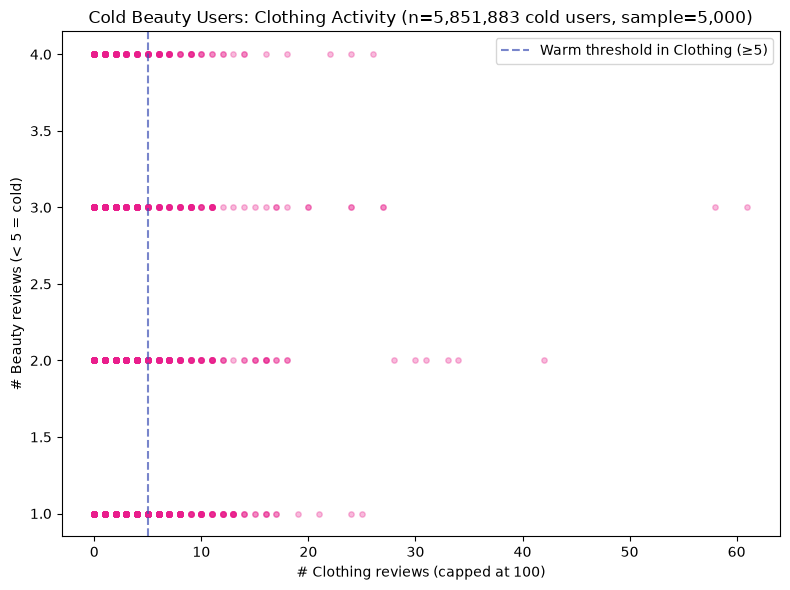

In [19]:
sample = cold_in_beauty.sample(min(5000, len(cold_in_beauty)), random_state=RANDOM_SEED)

plt.figure(figsize=(8, 6))
plt.scatter(
    sample["clothing_count"].clip(upper=100),
    sample["beauty_count"],
    alpha=0.3, s=15, c=COLORS[CATEGORIES[0]]
)
plt.axvline(x=WARM_USER_MIN_REVIEWS, color=COLORS[CATEGORIES[1]], ls="--", alpha=0.7,
            label=f"Warm threshold in Clothing (≥{WARM_USER_MIN_REVIEWS})")
plt.xlabel("# Clothing reviews (capped at 100)")
plt.ylabel("# Beauty reviews (< 5 = cold)")
plt.title(f"Cold Beauty Users: Clothing Activity (n={cold_count:,} cold users,"
          f" sample={len(sample):,})")
plt.legend()
plt.tight_layout()
plt.show()

## Summary: Cross-Category Transfer Potential

In [23]:
pct_transfer = 100 * has_clothing_warm / cold_count

print(f"Overall overlap rate:      {100 * len(overlap) / max(len(beauty_users), 1):.1f}% of Beauty users also shop in Clothing")
print(f"Cold Beauty users:          {cold_count:,} ({100*cold_count/total_beauty:.1f}%)")
print(f"Addressable via transfer:   {has_clothing_warm:,} cold Beauty users are warm in Clothing ({pct_transfer:.1f}%)\n")
print(f"Rating correlation:         r = {rating_r:.4f}  (modest positive, r\u00b2 \u2248 0.07)")
has_sparse = has_clothing_any - has_clothing_warm
print(f"Activity correlation (log): r = {act_r_log:.4f}  (heavy shoppers in one tend to be heavy in the other)")
print(f"Additional signal:          {has_sparse:,} cold users have 1-4 Clothing reviews ({100*has_sparse/cold_count:.1f}%)\n")
print(f"Design implication: {has_clothing_warm:,} users ({pct_transfer:.1f}% of cold Beauty users) have")
print("sufficient Clothing interaction history (≥5 reviews) for cross-domain")
print(f"transfer. Another {has_sparse:,} ({100*has_sparse/cold_count:.1f}%) have sparse (1-4) Clothing signal.")

Overall overlap rate:      53.8% of Beauty users also shop in Clothing
Cold Beauty users:          5,851,883 (95.1%)
Addressable via transfer:   591,576 cold Beauty users are warm in Clothing (10.1%)

Rating correlation:         r = 0.2658  (modest positive, r² ≈ 0.07)
Activity correlation (log): r = 0.3961  (heavy shoppers in one tend to be heavy in the other)
Additional signal:          2,458,239 cold users have 1-4 Clothing reviews (42.0%)

Design implication: 591,576 users (10.1% of cold Beauty users) have
sufficient Clothing interaction history (≥5 reviews) for cross-domain
transfer. Another 2,458,239 (42.0%) have sparse (1-4) Clothing signal.
